In [1]:
import numpy as np
import pandas as pd
import os
import json
import utils.saveload as sl
import models.snov.run_gabor_knov_complex as gknovc
import fitting_neural.grid_search_snov as gsc
import fitting_neural.simulate_data as sd
import models.snov.gabor_stimuli as gs
import fitting_neural.load_homann_data as load_homann
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm

%load_ext autoreload
%autoreload 2

In [2]:
# Define the variations of component functions to be investigated
def k_triangle(x,loc,scale): 
    return 1/scale*(1-np.abs(x-loc)/scale)*np.heaviside(1-np.abs(x-loc)/scale,0)

def k_triangle2(x,loc,scale):  # here: loc is the maximum value, scale is the steepness of the triangle
    return scale*x*np.heaviside(x,0)*np.heaviside(loc/scale-x,1) + loc*np.heaviside(x-loc/scale,0)

def k_triangle3(x,loc,scale):  # here: loc is the maximum value, scale is the steepness of the triangle
    return (1-np.abs(x-loc)/scale)*np.heaviside(1-np.abs(x-loc)/scale,0)

In [3]:
def k_id(s, scale, loc):
    return s

# Code for Figure S3 F

In [4]:
plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')
path_save = os.path.join(sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_neural_pred')
sl.make_long_dir(path_save)

## Panel 1: Visualize width variation (plot components)

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_11758/554221557.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = plt.cm.get_cmap('Reds')


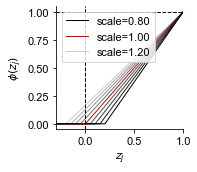

In [5]:
x = np.linspace(-1,1,1000)

loc = 1

scale1 = [0.8, 0.85, 0.9, 0.95]
scale2 = [1.05, 1.1, 1.15, 1.2]
scale = scale1 + [1.0] + scale2

vmax   = 4 + 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_p = plt.cm.get_cmap('Reds')
smap_p = cm.ScalarMappable(norm=cnorm, cmap=cmap_p)
myred  = smap_p.to_rgba(vmax-1)
cols   = ['k']*len(scale1) + [myred] + ['k']*len(scale2)

# alphas1 = list(np.linspace(0.2,1,len(scale1)))
# alphas2 = list(np.linspace(0.2,1,len(scale2)))[::-1]
# alphas  = alphas1 + [1.0] + alphas2
alphas1 = list(np.linspace(0.2,1,len(scale1)+len(scale2)))[::-1]
alphas  = alphas1[:len(scale1)] + [1.0] + alphas1[len(scale1):]

f, ax = plt.subplots(1,1,figsize=(8.3/3,2.5),sharey=True)
for i in range(len(scale)):
    if i==0 or i==len(scale)-1 or cols[i]==myred:
        ax.plot(x,k_triangle3(x,loc,scale[i]),alpha=alphas[i],c=cols[i],label=f'scale={scale[i]:.2f}')
    else:
        ax.plot(x,k_triangle3(x,loc,scale[i]),alpha=alphas[i],c=cols[i])

ax.legend()

ax.axvline(0, color='k', linestyle='--')
ax.axhline(1, color='k', linestyle='--')
ax.set_xlim(-1,1)
ax.set_xlabel('$z_j$')
ax.set_ylabel('$\phi(z_j)$')
ax.set_xlim([-0.3,1])
ax.spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.savefig(os.path.join(path_save,'SI_width_variation_components.svg'))


## Panel 2: Get distribution of similarities present in the data set

### Generate stimuli

In [6]:
def gen_images(num_images, seed=98765):
    # Generate test images
    params_input = {'num_gabor': 40,
                    'adj_w':     True,
                    'adj_f':     False,
                    'alph_adj':  3,
                    'n_fam':     [1,3,8,18,38],
                    'n_im':      [3,6,9,12],
                    'dN':        list(np.array([0,22,44,66,88,110,143])/0.3), # number of recovery images presented, computed based read out from Homann graphs #[0,70,140,210,280,360,480]
                    'idx':       True
                    }

    rng = np.random.default_rng(seed)
    dim_ranges = gs.dim_ranges_rad.copy()

    im_params_all = []
    im_all = []
    for i in range(num_images):
        im_params = gs.generate_stim(dim_ranges,params_input['num_gabor'],rng,alph_adj=params_input['alph_adj'],adj_w=params_input['adj_w'],adj_f=params_input['adj_f'],sampling='basic')
        im,_ = gs.comp_gabor(dim_ranges[4],dim_ranges[5],im_params,resolution=100,magn=1)
        im_params_all.append(im_params)
        im_all.append(im)

    im_params_all = np.array(im_params_all)
    im_all = np.array(im_all)

    return im_params_all, im_all


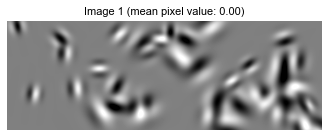

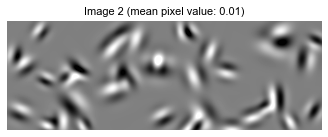

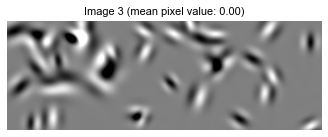

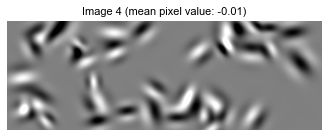

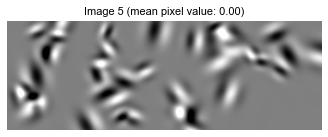

In [7]:
im_params_all, im_all = gen_images(100, seed=98765)

for i in range(min(5,im_all.shape[0])):
    plt.figure(figsize=(2* im_all.shape[2] / im_all.shape[1],2))
    plt.imshow(im_all[i,:,:], cmap='gray', vmin=-1, vmax=1)
    plt.title(f'Image {i+1} (mean pixel value: {np.mean(im_all[i,:,:]):.2f})')
    plt.axis('off')
    plt.show()  # Display each image one by one

In [8]:
# Compute component activation vectors for each model
def make_model(k_params_ext={}, kwargs_ext={}, input_params_ext={}, save_path_i=None):
    k_params = {'knum':             4,
                'type_complex':     8,
                'ratio_complex':    1/3,
                'num_complex':      8/3,
                'k_type':           'triangle',
                'cdens':            4,
                'k_alph':           0.1,
                'alph_leak':        0.1,
                'eps':              1e-6,
                'ksig':             1,
                'kcenter':          1,
                'conv':             True,
                'gabor_seed':       12345,
                'gabor_sampling':   'equidist_fixed'
                }
    
    kwargs = {'no_simple_cells':    False,
                'no_complex_cells': False,
                'mode_complex':     'sum', # 'sum' or 'mean'
                'debug':            False,
                'append_mode':      False,
                'start_id':         0,
                'savepath_sim_data': save_path_i,
                'savename_sim_data': 'sim_data_all',
                'record':           'all'
                }

    if 'type_complex' in k_params:
        kwargs['type_complex'] = [k_params['type_complex']]

    input_params = {'adj_w': True,
                    'adj_f': False,
                    'alph_adj': 3}

    # Update parameters
    k_params.update(k_params_ext)
    kwargs.update(kwargs_ext)
    input_params.update(input_params_ext)

    # Initialize Gabor kernel novelty model 
    k_params_components = gknovc.init_gabor_knov(gnum_complex=k_params['knum'],       # complex cells: number of different preferred orientations  
                                                    ctype=kwargs['type_complex'],       # complex cells: how many simple cells are pooled
                                                    dfreq=1.5,                           # complex cells: factor between simple cell frequencies (fixed at default)
                                                    cvar='frequency',                    # complex cells: feature of simple cells to be varied (fixed at default)
                                                    k_type=k_params['k_type'],           # simple cells: component shape
                                                    ksig=k_params['ksig'],               # simple cells: component width
                                                    kcenter=k_params['kcenter'],         # simple cells: component center (in similarity space)
                                                    seed=k_params['gabor_seed'],         # simple cells: seed for component generation 
                                                    rng=None,
                                                    mask=False,                          # simple cells: Gaussian mask if True (fixed at default False)
                                                    sampling=k_params['gabor_sampling'], # simple cells: sampling of preferred features (e.g. equidistant, random, ...)
                                                    adj_w=input_params['adj_w'],
                                                    adj_f=input_params['adj_f'],
                                                    alph_adj=input_params['alph_adj'],
                                                    conv=k_params['conv'],               # simple cells: convolutional simple cells if True
                                                    cdens=k_params['cdens'],             # simple cells: convolutional stride length 
                                                    parallel=False,                      # simple cells: parallel computation of activation matrix if True   
                                                    debug=kwargs['debug'] if 'debug' in kwargs else False
                                                )

    k_params.update(k_params_components)

    return k_params, kwargs

In [9]:
def get_model_activations(k_params, kwargs, stim_unique):

    # Initialize novelty model & extract kmat_seq
    k                   = k_params['k']
    kfun_idx            = k_params['kfun_idx']
    kfun_complex_idx    = k_params['kfun_complex_idx']
    ksig0               = k_params['ksig']
    cdens               = k_params['cdens'] if 'cdens' in k_params.keys() else None
    conv                = True if 'cdens' in k_params.keys() else False

    if conv:
        num_conv = stim_unique[0,::cdens,::cdens].size
        _, _, kmat_seq, _, klen = gknovc.init_nov_conv(k,kfun_idx,kfun_complex_idx,ksig0,num_conv,seq=stim_unique,kwargs=kwargs)
    else:
        _, _, kmat_seq, _, klen = gknovc.init_nov(k,kfun_idx,kfun_complex_idx,ksig0,seq=stim_unique,kwargs=kwargs)

    return kmat_seq, klen


In [10]:
kmat_id_all = []
klen_id_all = []
klim_id_all = []
klim_simple_id_all = []
for i in range(im_all.shape[0]):
    model_id = make_model(k_params_ext={'k_type': 'id', 'ksig':1}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_id, klen_id = get_model_activations(model_id[0], model_id[1], im_all[i,:,:][None,:,:])
    klim_id = [np.min(kmat_id), np.max(kmat_id)]
    klim_simple_id = [np.min(kmat_id[:klen_id[0]*klen_id[2]]), np.max(kmat_id[:klen_id[0]*klen_id[2]])]
    kmat_id_all.append(kmat_id)
    klen_id_all.append(klen_id)
    klim_id_all.append(klim_id)
    klim_simple_id_all.append(klim_simple_id)

klim_id_all = np.array(klim_id_all)
klim_simple_id_all = np.array(klim_simple_id_all)

### Plot panel

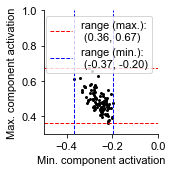

In [11]:
f,ax = plt.subplots(1,1, figsize=(2.5,2.5))
ax.axhline(y=np.min(klim_id_all[:,1]), color='r', linestyle='--', lw=1)
ax.axhline(y=np.max(klim_id_all[:,1]), color='r', linestyle='--', lw=1, label=f'range (max.):\n ({np.min(klim_id_all[:,1]):.2f}, {np.max(klim_id_all[:,1]):.2f})')
ax.axvline(x=np.max(klim_id_all[:,0]), color='b', linestyle='--', lw=1)
ax.axvline(x=np.min(klim_id_all[:,0]), color='b', linestyle='--', lw=1, label=f'range (min.):\n ({np.min(klim_id_all[:,0]):.2f}, {np.max(klim_id_all[:,0]):.2f})')

# ax.axhline(y=np.mean(klim_id_all[:,1]), color='r', linestyle=':', lw=1.5, label=f'mean(max act) = {np.mean(klim_id_all[:,1]):.2f}')
# ax.axvline(x=np.mean(klim_id_all[:,0]), color='b', linestyle=':', lw=1.5, label=f'mean(min act) = {np.mean(klim_id_all[:,0]):.2f}')
ax.scatter(klim_id_all[:,0],klim_id_all[:,1], c='k', s=4)
ax.set_xlabel('Min. component activation')
ax.set_ylabel('Max. component activation')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
eps = 0.2
ax.set_xlim([-0.5, 0])
ax.set_ylim([0.3, 1])
# ax.set_xlim([klim_id_all[:,0].min()-eps, klim_id_all[:,0].max()+eps])
# ax.set_ylim([klim_id_all[:,1].min()-eps, klim_id_all[:,1].max()+eps])
f.tight_layout()
f.savefig(os.path.join(path_save,'SI_width_variation_activation-range.svg'))

## Panel 3: Robustness fit

In [12]:
# Specify models 
# model_names    = ['snov-complex-fr'] # model whose robustness is tested
# compare_model  = ['cnov_fr'] # model to compare with
model_names   = ['snov-complex-leaky'] # model whose robustness is tested
compare_model = ['cnov_leaky'] # model to compare with

set_testmodel = [1] # set of the model whose robustness is tested
type_update   = [mn.split('-')[-1] for mn in model_names]
    
# Set plot labels
# label_test_model    = ['Sim.-based (flr)']
# label_compare_model = ['Count-based (fr)'] 
label_test_model    = ['Sim.']
label_compare_model = ['Counts'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = sl.get_rootpath() / 'data' / 'grid_search_results'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw     = best_params_fr + best_params_leaky
best_params         = [[bp for bp in best_params_raw if bp[0]==mn][0][1] for mn in model_names]
compare_params      = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# Load robustness grid (LR refit with partial model refit)
sampling_type   = 'normal'
weighting       = 'equal-samples'
set_names       = [2]

path_robustness = [sl.get_rootpath() / 'data' / 'gridsearch_robustness_width' / f'{mn}_set{sn}_sep' / 'combined_data'
                   for mn, sn in zip(model_names, set_names)]

grid_files = [os.path.join(pr, f'grid_{sampling_type}-{weighting}.csv') for pr in path_robustness]

grid = [pd.read_csv(gf) for gf in grid_files]

for i in range(len(grid)):
    if not 'k_type' in grid[i].columns:
        grid[i]['k_type'] = 'triangle'
    grid[i] = grid[i].sort_values(by=['k_type', 'ksig'])

# Load robustness grid (only LR refit)
set_names2      = [1]
sampling_type2  = 'normal'
weighting2      = 'equal-samples'

path_robustness2 = [sl.get_rootpath() / 'data' / 'gridsearch_robustness_width' / f'{mn}_set{sn}_sep' / 'combined_data'
                   for mn, sn in zip(model_names, set_names2)]

grid_files2 = [os.path.join(pr, f'grid_{sampling_type2}-{weighting2}.csv') for pr in path_robustness2]

grid2= [pd.read_csv(gf) for gf in grid_files2]

for i in range(len(grid2)):
    if not 'k_type' in grid2[i].columns:
        grid2[i]['k_type'] = 'triangle'
    grid2[i] = grid2[i].sort_values(by=['k_type', 'ksig'])

In [13]:
grid[0]

,Unnamed: 0,cdens,knum,ksig,type_complex,alph_leak,eps,num_complex,grid_id,save_path,grid_id_old,coef,shift,train_rss,train_mse,train_nmse,k_type
0,0,8,2,0.8,8,0.0,0.100000,2.666667,0,NaN,0,0.006716,0.023294,0.000411,0.000021,0.046951,triangle
1,1,8,2,0.8,8,0.0,0.010000,2.666667,1,NaN,1,0.004753,0.045486,0.000353,0.000018,0.040300,triangle
2,2,8,2,0.8,8,0.0,0.001000,2.666667,2,NaN,2,0.003578,0.054304,0.000343,0.000017,0.039180,triangle
3,3,8,2,0.8,8,0.0,0.000100,2.666667,3,NaN,3,0.002810,0.058559,0.000360,0.000018,0.041058,triangle
4,4,8,2,0.8,8,0.0,0.000010,2.666667,4,NaN,4,0.002306,0.061175,0.000374,0.000019,0.042698,triangle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,3,8,2,1.2,8,0.6,0.000100,2.666667,1051,NaN,3,-1.074772,0.345238,0.000751,0.000038,0.085792,triangle
1052,4,8,2,1.2,8,0.6,0.000010,2.666667,1052,NaN,4,-1.424040,-0.013212,0.000752,0.000038,0.085847,triangle
1053,5,8,2,1.2,8,0.6,0.000001,2.666667,1053,NaN,5,-1.524794,-0.080685,0.000752,0.000038,0.085823,triangle
1054,6,8,2,1.2,8,0.7,0.100000,2.666667,1054,NaN,6,1495.210053,-2087.466879,0.000456,0.000023,0.052013,triangle


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_11758/4037325681.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = plt.cm.get_cmap('Reds')


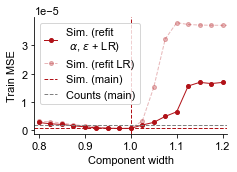

In [14]:
# Plot robustness grid
k_type_plot = 'triangle'
vmax   = 4 + 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_p = plt.cm.get_cmap('Reds')
smap_p = cm.ScalarMappable(norm=cnorm, cmap=cmap_p)
myred  = smap_p.to_rgba(vmax-1)
model_cols = [myred, myred]
models_dash = ['--']

f, ax = plt.subplots(1, 1, figsize=(3.4, 2.5))
for i in range(len(grid)):

    best_params[i]['ksig'] = 1.0

    # Get best params for each ksig, for model i (using train MSE after refitting LR)
    grid_i = grid[i].loc[grid[i]['k_type']==k_type_plot]
    grid_i = pd.concat([grid_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid_iagg = grid_i[['ksig','train_mse']].groupby(['ksig']).agg(best_train_mse=pd.NamedAgg(column='train_mse', aggfunc='min')) 
    grid_i = grid_i.merge(grid_iagg, on=['ksig'],how='left')
    grid_ibest = grid_i.loc[grid_i['train_mse']==grid_i['best_train_mse']].reset_index(drop=True)
    grid_ibest = grid_ibest.sort_values(by=['ksig'])
    ax.plot(grid_ibest['ksig'], grid_ibest[measure_fit], marker='o', markersize=4, ls='-', c=model_cols[i], label=f'{label_test_model[i]} (refit\n $\\alpha$, $\\epsilon$ + LR)')

    # Get best params for each ksig, for model i (using train MSE after refitting novelty update parameters and LR)
    grid2_i = grid2[i].loc[grid2[i]['k_type']==k_type_plot]
    grid2_i = pd.concat([grid2_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid2_i = grid2_i.sort_values(by=['ksig'])
    ax.plot(grid2_i['ksig'], grid2_i[measure_fit], marker='o', markersize=4, ls='--', c=model_cols[i], label=f'{label_test_model[i]} (refit LR)', alpha=0.3)

    ax.axhline(y=best_params[i][measure_fit], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model[i]} (main)')
    # ax.scatter(1,best_params[i][measure_fit], c=model_cols[i], marker='x',s=50)
    ax.axvline(x=1.0, c=model_cols[i], ls='--')

# ax.axvline(x=0.875, c='k', ls='--', label='ksig=0.875')

alph_compare = [1] if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for i in range(len(compare_params)):
    ax.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=f'{label_compare_model[i]} (main)')
ax.set_xlabel('Component width')
eps_xx= 0.01
ax.set_xlim([0.8-eps_xx,1.2+eps_xx])
ax.set_ylabel(label_opt_meas)
ax.legend(loc='upper left', handlelength=1.2)
ax.spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.savefig(os.path.join(path_save,'SI_width_variation_fit.svg'))